# Import and Global Param


In [1]:
# Import modules
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from jax import config
import numpy as np
os.environ["USE_MASSIVE_NEUTRINOS"] = "0" #Def we use normal DISCO-DJ or Massive neutrinos version
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
print(device)

from discodj import DiscoDJ
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)

import baccoemu

%matplotlib inline
from classy import Class
from scipy.optimize import fsolve
from scipy.interpolate import interp1d

jax.config.update("jax_enable_x64", True) 
import jax.numpy as jnp
from discoeb.background import evolve_background
from discoeb.perturbations import evolve_perturbations, get_power, evolve_perturbations_batched


#from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
#mpl.use("pgf")
#mpl.rcParams.update({
#    "pgf.texsystem": "pdflatex",
#    "font.family": "serif",
#    "text.usetex": True,
#})


gpu
0.7.2


/home/raphael/venv/discodj_env/lib/python3.12/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [ ]:
## Cosmological Parameters
Tcmb    = 2.7255
YHe     = 0.248
Omegam  = 0.3099
Omegab  = 0.0488911
Omegac  = Omegam - Omegab
Omegak  = 0 
w_DE_0  = -0.99
w_DE_a  = 0.0
cs2_DE  = 1.0
# Initialize neutrinos.
num_massive_neutrinos = 1
mnu     = 0.06  #eV
Tnu     = (4/11)**(1/3) #0.71611 # Tncdm of CLASS
Neff    = 3.046 # -1 if massive neutrino present
N_nu_mass = 1
N_nu_rel = Neff - N_nu_mass * (Tnu/((4/11)**(1/3)))**4
h       = 0.67742
A_s     = 3.5e-09
n_s     = 0.96822
k_p     = 0.05

# modes to sample
nmodes = 512
kmin = 1e-3
kmax = 10
aexp = 1.0
zout = 0.0

k = np.logspace(-3, np.log10(4.9), 100)

def Omega_nu(mnu,h) :
    return (mnu)/(93.14*(h**2))
print(Omegac)

f_nu = conv = Omega_nu(0.4,h) / (Omegam)
supp_P = 1-8*f_nu
supp_Pcb = 1-6*f_nu
print(Omegac)

0.2610089
0.2610089


# Reference Codes


## BACCO

In [59]:
params = {
    'omega_baryon': Omegab ,
    'omega_matter': Omegab+Omegac,
    'hubble': h,
    'ns': n_s,
    'neutrino_mass':0,
    # augmenté
    'A_s': A_s,

    'neutrino_mass': 0.0,
    'w0': w_DE_0,
    'wa': w_DE_a,
    'expfactor': 1
}

results_bacco = []
results_bacco_nl = []

plt.figure(figsize=(7,5))
mass_colors = {
    0: "#003f5c",  # dark blue
    0.4: "#bc5090", # magenta
    0.6: "#ffa600",  # yellow-orange
}

k = np.logspace(-3, np.log10(4.9), 100)

#Define the emulator
emulator = baccoemu.Matter_powerspectrum(baryonic_model_name='Burger2025')


# Computation of Linear spectra for massless 
k_ref, pk_ref = emulator.get_linear_pk(k=k,cold=True,**params)

# Computation of sigma8
sigma8_ref = emulator.get_sigma8(cold=True,**params)
params_nl_ref = params.copy()
params_nl_ref.pop('A_s')
params_nl_ref['sigma8_cold'] = sigma8_ref

# Computation of Non-Linear spectra for massless 
k_nl_ref, pk_nl_ref = emulator.get_nonlinear_pk(
    k=k,
    cold=True,
    allow_extrapolation=True,
    **params_nl_ref
)

# Save the Massless Linear
np.savetxt(
    "Pk_cb_massless_z0_BACCO.txt",
    np.column_stack([k_ref/h, pk_ref]),
    header="k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, massless neutrinos)"
)

# Save the ratios
results_bacco.append({
        "k": k_ref,
        "Pcb": pk_ref,
        "mass": 0,
        "method": "BACCO"
    })

results_bacco_nl.append({
        "k": k_nl_ref,
        "Pcb": pk_nl_ref,
        "mass": 0,
        "method": "BACCO_NL"
    })

plt.loglog(k_ref/h,pk_ref, label='$\sum m_i = '+str(0)+'$eV', color=mass_colors[0])
plt.loglog(k_nl_ref/h,pk_nl_ref,color="#2f4b7c" , label='$\sum m_i = '+str(0)+'$eV NL')

#Neutrino masses 
masses = [0.4]


for mass in masses:

    pars = params.copy()

    #Modify the param for the massive neutrinos
    pars['neutrino_mass'] = mass
    pars['omega_matter'] = Omegac+ Omegab + Omega_nu(mass,h)

    # Computation of Linear spectra for massive 
    k_lin, pk_lin = emulator.get_linear_pk(
        k=k,
        cold=True,
        **pars
    )
    ratio_lin = pk_lin / pk_ref

    # Computation of sigma8
    sigma8 = emulator.get_sigma8(cold=True,**pars)
    pars_nl = pars.copy()
    pars_nl['sigma8_cold'] = sigma8
    pars_nl.pop('A_s')

    # Computation of Non-Linear spectra for massive
    k_nl, pk_nl = emulator.get_nonlinear_pk(
        k=k,
        cold=True,
        allow_extrapolation=True,
        **pars_nl
    )
    ratio_nl = pk_nl / pk_nl_ref

    # Save the Massive Non-Linear
    fname = f"Pk_cb_sumMnu_{mass:.2f}eV_z0_BACCO.txt"
    np.savetxt(
        fname,
        np.column_stack([k_lin/h, pk_lin]),
        header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, sum m_nu = {mass} eV)"
    )

    # Save the ratios
    results_bacco.append({
        "k": k_lin,
        "Pcb": pk_lin,
        "mass": mass,
        "method": "BACCO"
    })

    results_bacco_nl.append({
        "k": k_nl,
        "Pcb": pk_nl,
        "mass": mass,
        "method": "BACCO_NL"
    })

    plt.loglog(k_lin/h,pk_lin, label='$\sum m_i = '+str(mass)+'$eV', color=mass_colors[mass])
    plt.loglog(k_nl/h,pk_nl,color="#ef5675"  ,label='$\sum m_i = '+str(mass)+'$eV NL')
    

plt.xlabel(r'$k [h \mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P_{cb}(k)\ [\mathrm{h}^{-3}\mathrm{Mpc}^{3}]$')  
plt.grid(True, which='both', ls='--')
plt.legend(fontsize=10)
plt.show()

np.save("bacco_results.npy", results_bacco)
np.save("bacco_results_nl.npy", results_bacco_nl)

<>:71: SyntaxWarning: invalid escape sequence '\s'
<>:72: SyntaxWarning: invalid escape sequence '\s'
<>:132: SyntaxWarning: invalid escape sequence '\s'
<>:133: SyntaxWarning: invalid escape sequence '\s'
<>:71: SyntaxWarning: invalid escape sequence '\s'
<>:72: SyntaxWarning: invalid escape sequence '\s'
<>:132: SyntaxWarning: invalid escape sequence '\s'
<>:133: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3794011/3032028852.py:71: SyntaxWarning: invalid escape sequence '\s'
  plt.loglog(k_ref/h,pk_ref, label='$\sum m_i = '+str(0)+'$eV', color=mass_colors[0])
/tmp/ipykernel_3794011/3032028852.py:72: SyntaxWarning: invalid escape sequence '\s'
  plt.loglog(k_nl_ref/h,pk_nl_ref,color="#2f4b7c" , label='$\sum m_i = '+str(0)+'$eV NL')
/tmp/ipykernel_3794011/3032028852.py:132: SyntaxWarning: invalid escape sequence '\s'
  plt.loglog(k_lin/h,pk_lin, label='$\sum m_i = '+str(mass)+'$eV', color=mass_colors[mass])
/tmp/ipykernel_3794011/3032028852.py:133: SyntaxWarning: invalid

AssertionError: Param sigma8_cold=0.948883630490277 out of bounds [0.73, 0.9]

<Figure size 700x500 with 0 Axes>

## CLASS

<>:81: SyntaxWarning: invalid escape sequence '\s'
<>:128: SyntaxWarning: invalid escape sequence '\s'
<>:81: SyntaxWarning: invalid escape sequence '\s'
<>:128: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3794011/360661833.py:81: SyntaxWarning: invalid escape sequence '\s'
  plt.loglog(k,Pkbc_CLASS, label='$\sum m_i = '+str(0)+'$eV', color=mass_colors[0])
/tmp/ipykernel_3794011/360661833.py:128: SyntaxWarning: invalid escape sequence '\s'
  plt.loglog(k,Pkbc_CLASS_nu, label='$\sum m_i = '+str(sum_masses)+'$eV', color=mass_colors[sum_masses])


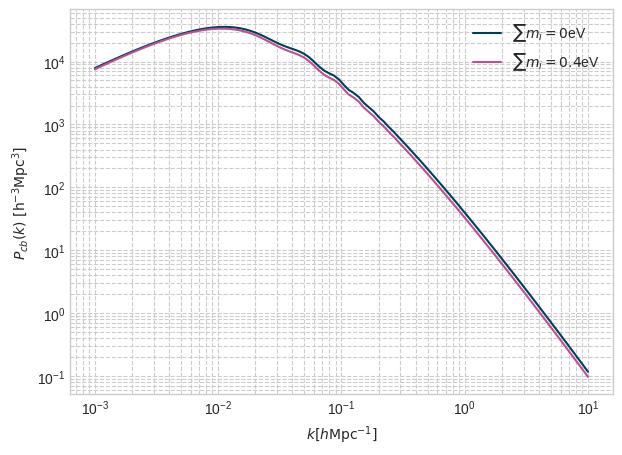

In [55]:
#Function to obtain PS
def get_class_power( fieldname, zout ):
  tk, k, z = cosmo_massless.get_transfer_and_k_and_z()
  TT = interp1d( np.log(1/(1+z)), tk[fieldname], axis=1 )( np.log(1/(1+zout)) ) 
  #res =  2*np.pi**2*A_s*(k/k_p*h)**(n_s - 1) * k**(-3) * TT**2 
  res =  2*np.pi**2*A_s*(k/k_p*h)**(n_s - 1) * k**(-3) * TT**2
  return res, k

#For save
results_class = []
plt.figure(figsize=(7,5))
mass_colors = {
    0: "#003f5c",  # dark blue
    0.4: "#bc5090", # magenta
    0.6: "#ffa600",  # yellow-orange
}

#Param
k = np.logspace(-3, 1, 100)
common_settings = {'output': 'mPk'}
cosmo_massless = Class()
params_massless = common_settings.copy()
params_massless.update({
    'Omega_k': 0.0,
    'Omega_b': Omegab,
    'Omega_cdm': Omegac,
    'h': h,
    'A_s': A_s,
    'n_s': n_s,
    'gauge': 'synchronous',
    'reio_parametrization': 'reio_none',
    'k_per_decade_for_pk': 100,
    'k_per_decade_for_bao': 100,
    'T_cmb': Tcmb,
    'YHe': YHe,
    'output': 'mPk,mTk,vTk',
    'P_k_max_1/Mpc': 2 * kmax,
    'z_max_pk': 1000.0,
    'recombination': 'RECFAST',
    'l_max_g': 31,
    'l_max_pol_g': 31,
    'l_max_ur': 31,
    'l_max_ncdm': 31,
    'Omega_Lambda': 0.0,
    'w0_fld': -0.99,
    'wa_fld': 0,
    'cs2_fld': 1.0,
    'use_ppf': 'no',
    'radiation_streaming_approximation': 2,
    'ncdm_fluid_approximation': 3,
    'ur_fluid_approximation': 2,
    'N_ur': 2.046,
    'N_ncdm': 1,
    'm_ncdm': 1e-10
})


#Set massless param & Compute cosmo
cosmo_massless.set(params_massless)
cosmo_massless.compute()


#Computation Massless Spectra CB
Pkbc_CLASS = np.array([cosmo_massless.pk_cb(ki, zout) for ki in k])*h**3

#Save the Massless for input
np.savetxt(
    "Pk_cb_massless_z0_CLASS.txt",
    np.column_stack([k, Pkbc_CLASS]),
    header="k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, massless neutrinos)"
)

#Save the Massless for plot
results_class.append({
        "k": k,
        "Pcb": Pkbc_CLASS,
        "mass": 0,
        "method": "CLASS"
    })

plt.loglog(k,Pkbc_CLASS, label='$\sum m_i = '+str(0)+'$eV', color=mass_colors[0])

for sum_masses in [0.4]:

    #Modify param for massive
    cosmo_massive = Class()
    params_massive = params_massless.copy()
    params_massive.update({
        'N_ncdm': 1,
        'deg_ncdm': 1,
        'm_ncdm': sum_masses,
        'Omega_cdm': Omegac,
        'N_ur': 2.046
    })

    #Set param & Compute Cosmo
    cosmo_massive.set(params_massive)
    cosmo_massive.compute()


    # Computation Massive CB spectra
    Pkbc_CLASS_nu = np.array([cosmo_massive.pk_cb(ki, zout) for ki in k])*h**3

    #Save PS for input
    fname = f"Pk_cb_sumMnu_{sum_masses:.2f}eV_z0_CLASS.txt"
    np.savetxt(
        fname,
        np.column_stack([k, Pkbc_CLASS_nu]),
        header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, sum m_nu = {sum_masses} eV)"
    )


    ratio = Pkbc_CLASS_nu / Pkbc_CLASS

    #Save spectrum for plot
    results_class.append({
        "k": k,
        "Pcb": Pkbc_CLASS_nu,
        "mass": sum_masses,
        "method": "CLASS"
    })

    #Clean
    cosmo_massive.struct_cleanup()
    cosmo_massive.empty()


    plt.loglog(k,Pkbc_CLASS_nu, label='$\sum m_i = '+str(sum_masses)+'$eV', color=mass_colors[sum_masses])
    

plt.xlabel(r'$k [h \mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P_{cb}(k)\ [\mathrm{h}^{-3} \mathrm{Mpc}^{3}]$')  
plt.grid(True, which='both', ls='--')
plt.legend(fontsize=10)
plt.show()

#Save and clean
np.save("class_results.npy", results_class)
cosmo_massless.struct_cleanup()
cosmo_massless.empty()

## DISCOEB

<>:60: SyntaxWarning: invalid escape sequence '\s'
<>:93: SyntaxWarning: invalid escape sequence '\s'
<>:60: SyntaxWarning: invalid escape sequence '\s'
<>:93: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3794011/184718601.py:60: SyntaxWarning: invalid escape sequence '\s'
  plt.loglog(kmodes,Pkm*h**3, label='$\sum m_i = '+str(0)+'$eV', color=mass_colors[0])
/tmp/ipykernel_3794011/184718601.py:93: SyntaxWarning: invalid escape sequence '\s'
  plt.loglog(kmodes,Pkm_nu*h**3, label='$\sum m_i = '+str(sum_masses)+'$eV', color=mass_colors[sum_masses])


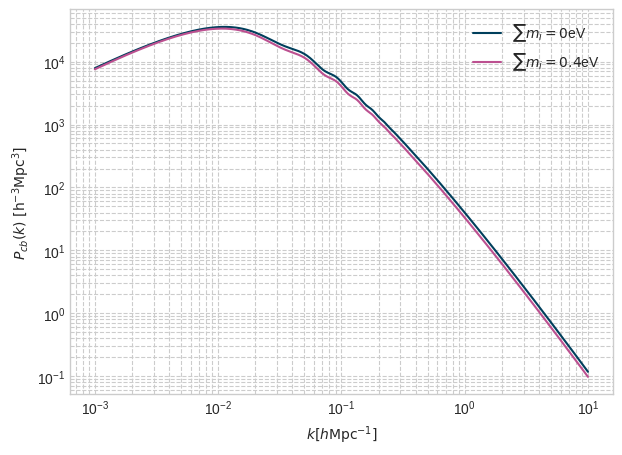

In [18]:
@jax.jit
def compute_matter_power( Omegam=0.3099, mnu=0.0):

    #Set param
    param = {}
    param['Omegam']  = Omegam         # Total matter density parameter
    param['Omegab']  = Omegab                           # Baryon density parameter
    param['w_DE_0']  = w_DE_0                           # Dark energy equation of state parameter today
    param['w_DE_a']  = w_DE_a                           # Dark energy equation of state parameter time derivative
    param['cs2_DE']  = cs2_DE                           # Dark energy sound speed squared
    param['Omegak']  = Omegak                           # Curvature density parameter
    param['A_s']     = A_s                              # Scalar amplitude of the primordial power spectrum
    param['n_s']     = n_s                              # Scalar spectral index
    param['H0']      = h*100                            # Hubble constant today in units of 100 km/s/Mpc
    param['Tcmb']    = Tcmb                             # CMB temperature today in K
    param['YHe']     = YHe                              # Helium mass fraction
    param['Neff']    = 2.046                            # Effective number of ultrarelativistic neutrinos                                          
    param['Nmnu']    = 1                                # Number of massive neutrinos (must be 1 currently)
    param['mnu']     = mnu                              # Sum of neutrino masses in eV 
    param['k_p']     =  k_p                             # Pivot scale in 1/Mpc
    
    # modes to sample
    nmodes = 512                         # number of modes to sample                        

    #Evolve Background
    param = evolve_background(param=param, thermo_module='RECFAST')
    aexp_out = jnp.array([aexp])

    #Evolve Perturbation
    y, kmodes = evolve_perturbations_batched( param=param, kmin=kmin, kmax=kmax, num_k=nmodes, aexp_out=aexp_out,
                                    lmaxg = 31, lmaxgp = 31, lmaxr = 31, lmaxnu = 31, nqmax = 5,
                                    max_steps=32768,
                                    rtol=1e-5, atol=1e-5, batch_size=32 )
    #Compute CB spectrum
    iout = -1
    fac = 2 * np.pi**2 * A_s
    Pkbc = fac *(kmodes/k_p)**(n_s - 1) * kmodes**(-3) * y[:,iout,6]**2

    return Pkbc, kmodes

#For Save
results_disco = []
plt.figure(figsize=(7,5))
mass_colors = {
    0: "#003f5c",  # dark blue
    0.4: "#bc5090", # magenta
    0.6: "#ffa600",  # yellow-orange
}

#Compute linear Massless CB spectrum
Pkm, kmodes = compute_matter_power( Omegam,0 )

#Save for input 
np.savetxt(
    "Pk_cb_massless_z0_DISCOEB.txt",
    np.column_stack([kmodes, Pkm*h**3]),
    header="k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, massless neutrinos)"
)

plt.loglog(kmodes,Pkm*h**3, label='$\sum m_i = '+str(0)+'$eV', color=mass_colors[0])

#save for plot
results_disco.append({
        "k": kmodes,
        "Pcb": Pkm*h**3,
        "mass": 0,
        "method": "DISCOEB"
    })


for sum_masses in [0.4]:

    #Compute Linear Massive CB spectrum
    Pkm_nu, kmodes_nu = compute_matter_power( Omegam,sum_masses )

    #Save for Plot 
    results_disco.append({
        "k": kmodes,
        "Pcb": Pkm_nu*h**3,
        "mass": sum_masses,
        "method": "DISCOEB"
    })

    #Save for input
    fname = f"Pk_cb_sumMnu_{sum_masses:.2f}eV_z0_DISCOEB.txt"
    np.savetxt(
        fname,
        np.column_stack([kmodes, Pkm_nu*h**3]),
        header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, sum m_nu = {sum_masses} eV)"
    )


    plt.loglog(kmodes,Pkm_nu*h**3, label='$\sum m_i = '+str(sum_masses)+'$eV', color=mass_colors[sum_masses])
    

plt.xlabel(r'$k [h \mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P_{cb}(k)\ [\mathrm{h}^{-3}\mathrm{Mpc}^{3}]$')  
plt.grid(True, which='both', ls='--')
plt.legend(fontsize=10)
plt.show()

np.save("discoeb_results.npy", results_disco)

## Linear Spectra

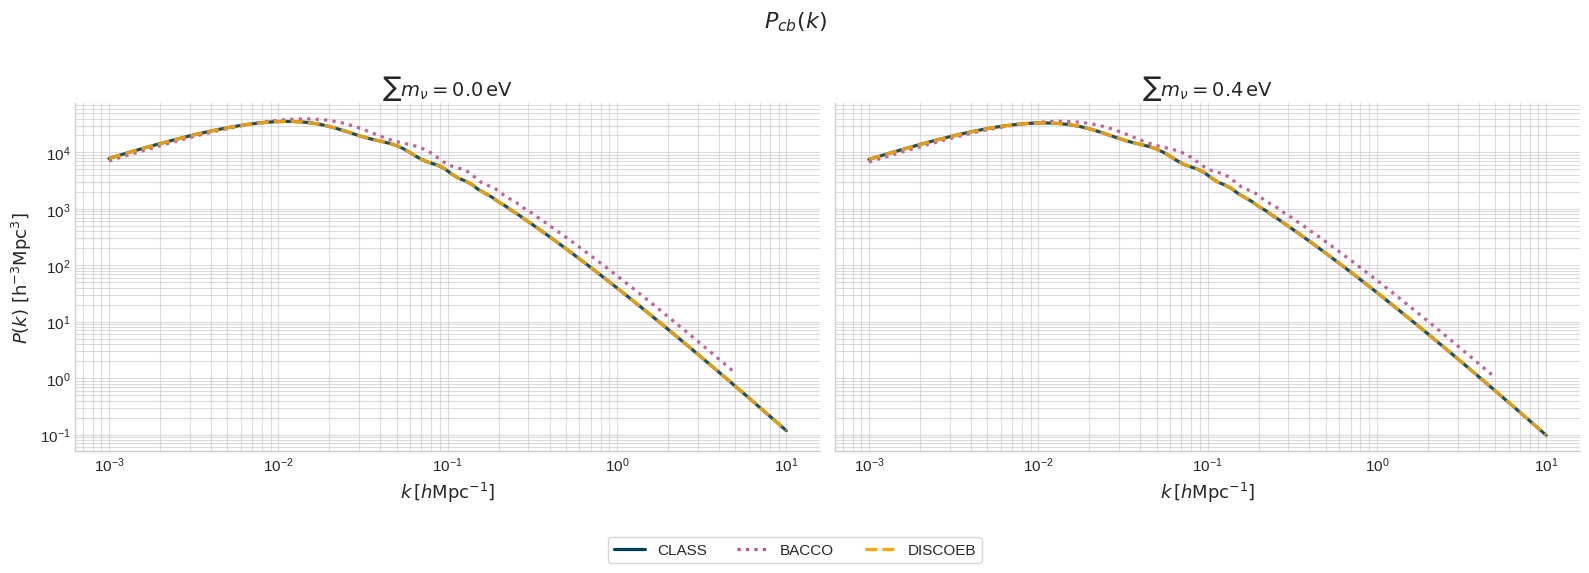

In [56]:
class_data   = np.load("class_results.npy", allow_pickle=True)
bacco_data   = np.load("bacco_results.npy", allow_pickle=True)
discoeb_data = np.load("discoeb_results.npy", allow_pickle=True)

all_data = (
    list(class_data)
    + list(bacco_data)
    + list(discoeb_data)
)

plt.style.use("seaborn-v0_8-whitegrid")

masses = [0.0, 0.4]

fig, axes = plt.subplots(
    1, len(masses),
    figsize=(16, 5),
    sharey=True
)

method_colors = {
    "CLASS": "#003f5c",
    "BACCO": "#bc5090",
    "DISCOEB": "#ffa600",
}

method_styles = {
    "CLASS": dict(
        ls="-",
        lw=2.3,
        alpha=0.9,
        zorder=3,
    ),
    "BACCO": dict(
        ls=":",
        lw=2.3,
        alpha=0.9,
        zorder=3,
    ),
    "DISCOEB": dict(
        ls="--",
        lw=2.3,
        alpha=0.9,
        zorder=3,
    ),
}

for ax, mass in zip(axes, masses):

    mass_data = [d for d in all_data if np.isclose(d["mass"], mass)]

    for d in mass_data:

        k      = d["k"]
        Pcb  = d["Pcb"]
        method = d["method"]

        if "BACCO" in method:
            key = "BACCO"
        elif "CLASS" in method:
            key = "CLASS"
        elif "DISCOEB" in method:
            key = "DISCOEB"

        ax.loglog(
            k,
            Pcb,
            color=method_colors[key],
            label=key,
            **method_styles[key]
        )

    ax.set_title(
        rf"$\sum m_\nu = {mass}\,\mathrm{{eV}}$",
        fontsize=14
    )

    ax.grid(True, which="both", linestyle="-", alpha=0.7)
    

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", which="major", labelsize=11)

    ax.set_xlabel(
        r"$k\,[h \mathrm{Mpc}^{-1}]$",
        fontsize=13
    )

axes[0].set_ylabel(
    r"$P(k)\ [\mathrm{h}^{-3}\mathrm{Mpc}^{3}]$",
    fontsize=13
)

method_handles = [
    Line2D(
        [0], [0],
        color=method_colors[m],
        lw=method_styles[m]["lw"],
        ls=method_styles[m]["ls"],
        label=m
    )
    for m in method_styles
]

fig.legend(
    handles=method_handles,
    loc="upper center",
    ncol=3,
    frameon=True,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    r"$P_{cb}(k)$",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

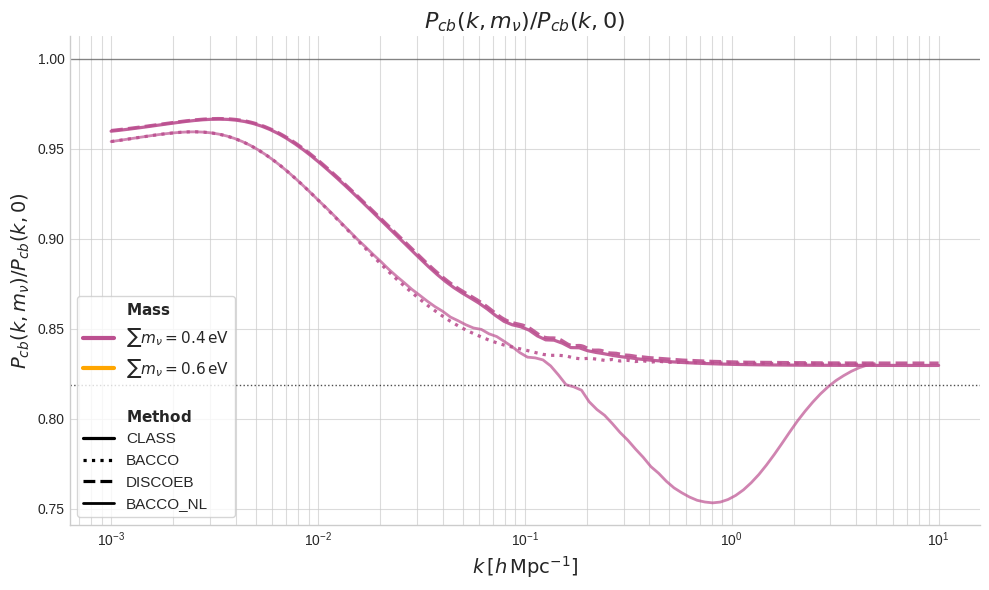

In [54]:
class_data   = np.load("class_results.npy", allow_pickle=True)
bacco_data   = np.load("bacco_results.npy", allow_pickle=True)
bacco_data_nl   = np.load("bacco_results_nl.npy", allow_pickle=True)
discoeb_data = np.load("discoeb_results.npy", allow_pickle=True)

all_data = (
    list(class_data)
    + list(bacco_data)
    + list(bacco_data_nl)
    + list(discoeb_data)
)

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

# Couleurs = masses
mass_colors = {
    0.0: "#003f5c",
    0.4: "#bc5090",
    0.6: "#ffa600",
}

# Styles = méthodes
method_styles = {
    "CLASS": dict(ls="-",  lw=2.3, alpha=0.9,zorder=2),
    "BACCO": dict(ls=":",  lw=2.3, alpha=0.9,zorder=3),
    "DISCOEB": dict(ls="--", lw=2.3, alpha=0.9,zorder=2),
    "BACCO_NL": dict(ls="-",lw=2.0,alpha=0.7,zorder=3),
}

# ------------------------------------------------------------------
# Construction des spectres de référence (mnu = 0)
# ------------------------------------------------------------------

reference = {}

for d in all_data:

    mass = d["mass"]

    if not np.isclose(mass, 0.0):
        continue

    method = d["method"]

    if "BACCO_NL" in method:
        key = "BACCO_NL"
    elif "BACCO" in method:
        key = "BACCO"
    elif "CLASS" in method:
        key = "CLASS"
    elif "DISCOEB" in method:
        key = "DISCOEB"

    reference[key] = d["Pcb"]

# ------------------------------------------------------------------
# Tracé des ratios
# ------------------------------------------------------------------

for d in all_data:

    mass = d["mass"]

    if np.isclose(mass, 0.0):
        continue

    k = d["k"]
    if "BACCO_NL" in d["method"]:
        key = "BACCO_NL"
    elif "BACCO" in d["method"]:
        key = "BACCO"
    elif "CLASS" in d["method"]:
        key = "CLASS"
    elif "DISCOEB" in d["method"]:
        key = "DISCOEB"

    ratio = d["Pcb"] / reference[key]

    ax.semilogx(
        k,
        ratio,
        color=mass_colors[mass],
        **method_styles[key]
    )

# ------------------------------------------------------------------
# Mise en forme
# ------------------------------------------------------------------

ax.set_xlabel(
    r"$k\,[h\,\mathrm{Mpc}^{-1}]$",
    fontsize=14
)

ax.set_ylabel(
    r"$P_{cb}(k,m_\nu)/P_{cb}(k,0)$",
    fontsize=14
)

ax.axhline(
    1.0,
    color="black",
    lw=1,
    alpha=0.4
)
ax.axhline(
    supp_Pcb,
    color="black",
    lw=1,
    ls=":", 
    alpha=0.7
)
ax.grid(True, which="both", alpha=0.7)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------------
# Légendes
# ------------------------------------------------------------------

mass_handles = [
    Line2D(
        [0], [0],
        color=mass_colors[m],
        lw=3,
        label=rf"$\sum m_\nu={m}\,\mathrm{{eV}}$"
    )
    for m in [0.4, 0.6]
]

method_handles = [
    Line2D(
        [0], [0],
        color="black",
        ls=method_styles[m]["ls"],
        lw=method_styles[m]["lw"],
        label=m
    )
    for m in method_styles
]

combined_handles = [
    Line2D([], [], color='none', label=r"$\bf{Mass}$"),
    *mass_handles,
    Line2D([], [], color='none', label=""),
    Line2D([], [], color='none', label=r"$\bf{Method}$"),
    *method_handles,
]

ax.legend(
    handles=combined_handles,
    loc="lower left",
    fontsize=11,
    frameon=True,
)

ax.set_title(
    r"$P_{cb}(k,m_\nu)/P_{cb}(k,0)$",
    fontsize=16
)

plt.tight_layout()
plt.show()

# N-body DISCODJ

## Linear Suppresion

In [28]:
emulator = baccoemu.Matter_powerspectrum(baryonic_model_name='Burger2025')
def sigma8_from_As(mnu,As):
    p = {
        'omega_cold': Omegac,
        'omega_baryon': Omegab,
        'hubble': h,
        'ns': n_s,
        'neutrino_mass':0,
        # augmenté
        'A_s': As,
        'neutrino_mass': mnu,
        'w0': w_DE_0,
        'wa': w_DE_a,
        'expfactor': 1
    }
    return  emulator.get_sigma8(cold=False,**p)


# Set the parameters
name = "3D_analysis"
dim = 3
precision = "double"
if precision == "double":
    config.update("jax_enable_x64", True)

# Define the boxsize and resolution
boxsize = 4000  # in Mpc/h
res = 128  # the particles live on a Lagrangrian grid of resolution (res)^dim

class_data = np.load("class_results.npy", allow_pickle=True)
class_dict = {(d["mass"], d["k"].shape[0]): d for d in class_data}
# (fallback simple mapping by mass only)
class_by_mass = {}
for d in class_data:
    class_by_mass.setdefault(d["mass"], d)

results_disco = []
###########################################################################################################################################################################
class_massless = class_by_mass[0.0]
k_class_0 = class_massless["k"]
pk_class_0 = class_massless["Pcb"]



# The cosmology can be provided as a dictionary or a string for a pre-defined cosmology (e.g. "CamelsCV" for the Camels Cosmic Variance suite).
# cosmo = "CamelsCV"
cosmo = dict(Omega_c=Omegac,  # cold dark matter content
             Omega_b=Omegab,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
             h=h,  # dimensionless Hubble constant
             n_s=n_s,  # scalar spectral index
             sigma8=0.8,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
             mnu = 0.0) #Neutrino mass (eV)

dj = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)
print(dj)
dj = dj.with_timetables()
dj = dj.with_linear_ps(fix_sigma8=True, transfer_function="Eisenstein-Hu")
white_noise_field = dj.get_ngenic_noise(seed=13)  # a white noise field, defined in real space
dj = dj.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
k_pre, Pk_pre, _ = dj.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)

n_order = 2
stepper = "bullfrog"
method = "pm"
res_pm = dj.res
time_var = "D"
antialias = 0
grad_kernel_order = 4
laplace_kernel_order = 0
worder = 2
n_resample = 1
deconvolve = True
nlpt_order_ics = n_order
chunk_size = None  # if you are running out of GPU memory, doing the mass assignment in smaller chunks might help (e.g. chunk_size = dj.res ** dj.dim // 16)

a_targets = [0.15, 0.33, 0.66, 1.0]

for a_end in a_targets:

    numsteps = 10  # number of steps to be performed
    a_ini = 0.02  # initial scale factor of the simulation (where it is initialized with LPT)
    a_list = np.linspace(a_ini, a_end, numsteps, endpoint=True)

    
    dj = dj.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
    X_sim, P_sim, a_sim = dj.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                    time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                    grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                    nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                    deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                    convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
    delta_sim = dj.get_delta_from_pos(X_sim, res= dj.res, n_resample=1)
    k, Pk, _ = dj.evaluate_power_spectrum(delta_sim, bins=dj.res//3, deconvolve=True, worder=2)

    results_disco.append({
            "k": k,
            "Pcb": Pk,
            "mass": 0,
            "method": "DISCODJ",
            "a": a_end                                                               
        }) 

###########################################################################################################################################################################


for sum_masses in [0.4]:
    
    class_massive = class_by_mass[sum_masses]
    k_class_m = class_massive["k"]
    pk_class_m = class_massive["Pcb"]

    cosmo_nu = dict(Omega_c=Omegac,  # cold dark matter content
                Omega_b=Omegab,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
                h=h,  # dimensionless Hubble constant
                n_s=n_s,  # scalar spectral index
                sigma8=0.8,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
                mnu = sum_masses) #Neutrino mass (eV)

    dj_nu = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo_nu)
    print(dj_nu)
    dj_nu = dj_nu.with_timetables()
    dj_nu = dj_nu.with_linear_ps(fix_sigma8=True, transfer_function="Eisenstein-Hu")
    dj_nu = dj_nu.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
    k_pre_nu, Pk_pre_nu, _ = dj_nu.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)
    
    for a_end in a_targets:

        numsteps = 10  # number of steps to be performed
        a_ini = 0.02  # initial scale factor of the simulation (where it is initialized with LPT)
        a_list = np.linspace(a_ini, a_end, numsteps, endpoint=True)

        dj_nu = dj_nu.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
        X_sim_nu, P_sim_nu, a_sim_nu = dj_nu.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                        time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                        grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                        nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                        deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                        convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
        delta_sim_nu = dj_nu.get_delta_from_pos(X_sim_nu, res= dj.res, n_resample=1)
        k_nu, Pk_nu, _ = dj_nu.evaluate_power_spectrum(delta_sim_nu, bins=dj.res//3, deconvolve=True, worder=2)

        results_disco.append({
            "k": k,
            "Pcb": Pk_nu,
            "mass": sum_masses,
            "method": "DISCODJ",
            "a": a_end                                                               
        })  

np.save("discodj_results.npy", results_disco)

DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 128³ particles
Boxsize: 4000.0 Mpc/h
Precision: double
Device: gpu
Cosmology:
  Omega_c: 0.2610 
  Omega_b: 0.0489 
  Omega_de: 0.6900 
  h: 0.6774 
  n_s: 0.9682 
  sigma8: 0.8000 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000 
  mnu: 0.0000 
DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 128³ particles
Boxsize: 4000.0 Mpc/h
Precision: double
Device: gpu
Cosmology:
  Omega_c: 0.2610 
  Omega_b: 0.0489 
  Omega_de: 0.6808 
  h: 0.6774 
  n_s: 0.9682 
  sigma8: 0.8000 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000 
  mnu: 0.4000 


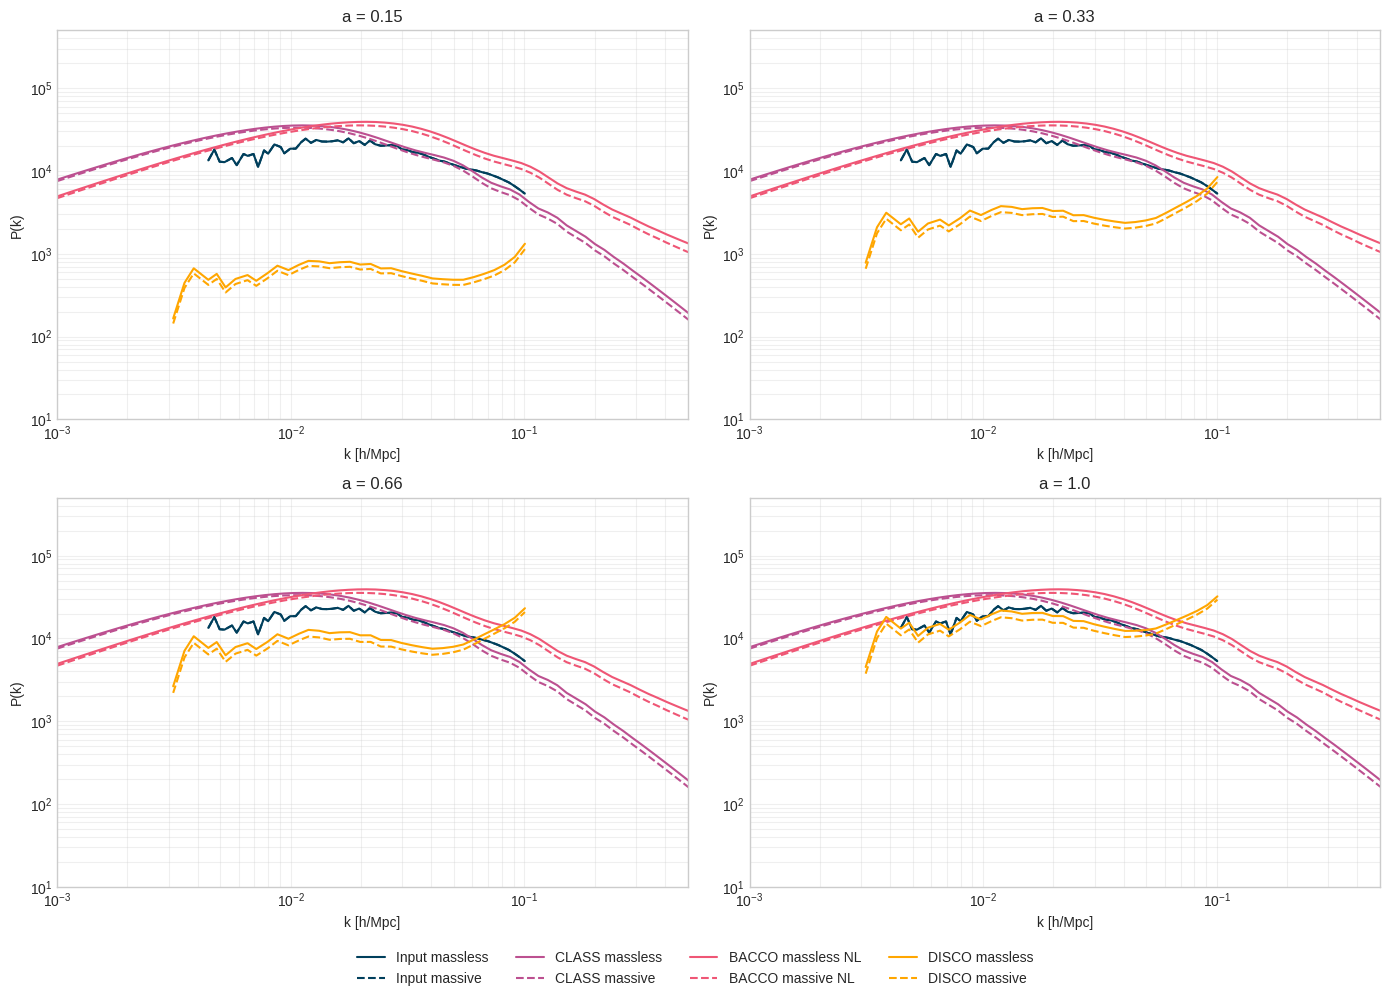

In [29]:
discodj_data = list(np.load("discodj_results.npy", allow_pickle=True))
class_data   = np.load("class_results.npy", allow_pickle=True)
bacco_data_nl   = np.load("bacco_results_nl.npy", allow_pickle=True)

colors = {
    "input": "#003f5c",
    "class": "#bc5090",
    "output": "#ffa600",
    "bacco": "#ef5675"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

bacco_massless = next(d for d in bacco_data_nl if np.isclose(d["mass"], 0.0))
k_bacco_0 = bacco_massless["k"]
pk_bacco_0 = bacco_massless["Pcb"]
bacco_massive =  next(d for d in bacco_data_nl if np.isclose(d["mass"], 0.4))
k_bacco_m = bacco_massive["k"]
pk_bacco_m = bacco_massive["Pcb"]


class_massless = next(d for d in class_data if np.isclose(d["mass"], 0.0))
k_class_0 = class_massless["k"]
pk_class_0 = class_massless["Pcb"]
class_massive =  next(d for d in class_data if np.isclose(d["mass"], 0.4))
k_class_m = class_massive["k"]
pk_class_m = class_massive["Pcb"]



for i, a_end in enumerate(a_targets):

    entries = [d for d in discodj_data if np.isclose(d["a"], a_end)]
    entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
    entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
    k = entry0["k"]
    Pk = entry0["Pcb"]
    Pk_nu = entrym["Pcb"]

    ax = axes[i]
    # -------- INPUT --------
    ax.plot(k_pre, Pk_pre, color=colors["input"], linestyle='-', label="Input massless")
    ax.plot(k_pre_nu, Pk_pre_nu,color=colors["input"], linestyle='--', label="Input massive")

    # -------- CLASS --------
    ax.plot(k_class_0, pk_class_0, color=colors["class"], linestyle='-', label="CLASS massless")
    ax.plot(k_class_m, pk_class_m, color=colors["class"], linestyle='--', label="CLASS massive")
    ax.plot(k_bacco_0, pk_bacco_0, color=colors["bacco"], linestyle='-', label="BACCO massless NL")
    ax.plot(k_bacco_m, pk_bacco_m, color=colors["bacco"], linestyle='--', label="BACCO massive NL")
    # -------- OUTPUT (DISCO) --------
    ax.plot(k, Pk, color=colors["output"], linestyle='-', label="DISCO massless")
    ax.plot(k, Pk_nu, color=colors["output"], linestyle='--', label="DISCO massive")
    ax.set_xlim(1e-3, 0.5)
    ax.set_ylim(10, 5e5)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"a = {a_end}")
    ax.set_xlabel("k [h/Mpc]")
    ax.set_ylabel("P(k)")
    ax.grid(True, which="both", alpha=0.3)

# legend unique
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

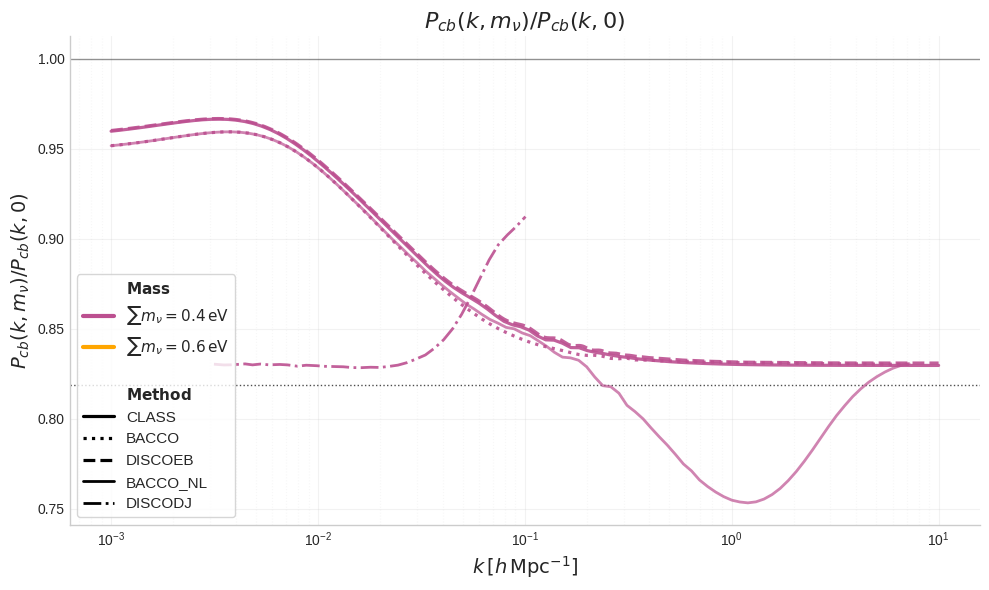

In [30]:
class_data   = np.load("class_results.npy", allow_pickle=True)
bacco_data   = np.load("bacco_results.npy", allow_pickle=True)
bacco_data_nl   = np.load("bacco_results_nl.npy", allow_pickle=True)
discoeb_data = np.load("discoeb_results.npy", allow_pickle=True)
discodj_data = np.load("discodj_results.npy", allow_pickle=True)
discodj_data = [d for d in discodj_data if np.isclose(d["a"], a_end)]

all_data = (
    list(class_data)
    + list(bacco_data)
    + list(bacco_data_nl)
    + list(discoeb_data)
    + list(discodj_data)
)

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

# Couleurs = masses
mass_colors = {
    0.0: "#003f5c",
    0.4: "#bc5090",
    0.6: "#ffa600",
}

# Styles = méthodes
method_styles = {
    "CLASS": dict(ls="-",  lw=2.3, alpha=0.9,zorder=2),
    "BACCO": dict(ls=":",  lw=2.3, alpha=0.9,zorder=3),
    "DISCOEB": dict(ls="--", lw=2.3, alpha=0.9,zorder=2),
    "BACCO_NL": dict(ls="-",lw=2.0,alpha=0.7,zorder=3),
    "DISCODJ": dict(ls="-.",lw=2.0,alpha=0.9,zorder=3),
}

reference = {}

for d in all_data:

    mass = d["mass"]

    if not np.isclose(mass, 0.0):
        continue

    method = d["method"]

    if "BACCO_NL" in method:
        key = "BACCO_NL"
    elif "BACCO" in method:
        key = "BACCO"
    elif "CLASS" in method:
        key = "CLASS"
    elif "DISCOEB" in method:
        key = "DISCOEB"
    elif "DISCODJ" in method:
        key = "DISCODJ"

    reference[key] = d["Pcb"]

for d in all_data:

    mass = d["mass"]

    if np.isclose(mass, 0.0):
        continue

    k = d["k"]
    if "BACCO_NL" in d["method"]:
        key = "BACCO_NL"
    elif "BACCO" in d["method"]:
        key = "BACCO"
    elif "CLASS" in d["method"]:
        key = "CLASS"
    elif "DISCOEB" in d["method"]:
        key = "DISCOEB"
    elif "DISCODJ" in d["method"]:
        key = "DISCODJ"

    ratio = d["Pcb"] / reference[key]

    ax.semilogx(
        k,
        ratio,
        color=mass_colors[mass],
        **method_styles[key]
    )

ax.set_xlabel(
    r"$k\,[h\,\mathrm{Mpc}^{-1}]$",
    fontsize=14
)

ax.set_ylabel(
    r"$P_{cb}(k,m_\nu)/P_{cb}(k,0)$",
    fontsize=14
)

ax.axhline(
    1.0,
    color="black",
    lw=1,
    alpha=0.4
)

ax.axhline(
    supp_Pcb,
    color="black",
    lw=1,
    ls=":", 
    alpha=0.7
)

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

mass_handles = [
    Line2D(
        [0], [0],
        color=mass_colors[m],
        lw=3,
        label=rf"$\sum m_\nu={m}\,\mathrm{{eV}}$"
    )
    for m in [0.4, 0.6]
]

method_handles = [
    Line2D(
        [0], [0],
        color="black",
        ls=method_styles[m]["ls"],
        lw=method_styles[m]["lw"],
        label=m
    )
    for m in method_styles
]

combined_handles = [
    Line2D([], [], color='none', label=r"$\bf{Mass}$"),
    *mass_handles,
    Line2D([], [], color='none', label=""),
    Line2D([], [], color='none', label=r"$\bf{Method}$"),
    *method_handles,
]

ax.legend(
    handles=combined_handles,
    loc="lower left",
    fontsize=11,
    frameon=True,
)

ax.set_title(
    r"$P_{cb}(k,m_\nu)/P_{cb}(k,0)$",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Non-linear Suppresion (Scale dep)

In [31]:
emulator = baccoemu.Matter_powerspectrum(baryonic_model_name='Burger2025')
def sigma8_from_As(mnu,As):
    p = {
        'omega_cold': Omegac+ Omega_nu(mnu,h),
        'omega_baryon': Omegab,
        'hubble': h,
        'ns': n_s,
        'neutrino_mass':0,
        # augmenté
        'A_s': As,
        'neutrino_mass': mnu,
        'w0': w_DE_0,
        'wa': w_DE_a,
        'expfactor': 1
    }
    return  emulator.get_sigma8(cold=False,**p)


# Set the parameters
name = "3D_analysis"
dim = 3
precision = "double"
if precision == "double":
    config.update("jax_enable_x64", True)

# Define the boxsize and resolution
boxsize = 2000  # in Mpc/h
res = 128  # the particles live on a Lagrangrian grid of resolution (res)^dim

class_data = np.load("class_results.npy", allow_pickle=True)
class_dict = {(d["mass"], d["k"].shape[0]): d for d in class_data}
# (fallback simple mapping by mass only)
class_by_mass = {}
for d in class_data:
    class_by_mass.setdefault(d["mass"], d)

results_disco = []
###########################################################################################################################################################################
class_massless = class_by_mass[0.0]
k_class_0 = class_massless["k"]
pk_class_0 = class_massless["Pcb"]



# The cosmology can be provided as a dictionary or a string for a pre-defined cosmology (e.g. "CamelsCV" for the Camels Cosmic Variance suite).
# cosmo = "CamelsCV"
cosmo = dict(Omega_c=Omegac,  # cold dark matter content
             Omega_b=Omegab,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
             h=h,  # dimensionless Hubble constant
             n_s=n_s,  # scalar spectral index
             sigma8=0.8,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
             mnu = 0.0) #Neutrino mass (eV)

dj = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)
print(dj)
dj = dj.with_timetables()
dj = dj.with_linear_ps(fix_sigma8=True, transfer_function="from_file", filename="Pk_cb_massless_z0_CLASS.txt")
white_noise_field = dj.get_ngenic_noise(seed=13)  # a white noise field, defined in real space
dj = dj.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
k_pre, Pk_pre, _ = dj.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)
print(k_pre)
print(Pk_pre)
n_order = 2
stepper = "bullfrog"
method = "pm"
res_pm = dj.res
time_var = "D"
antialias = 0
grad_kernel_order = 4
laplace_kernel_order = 0
worder = 2
n_resample = 1
deconvolve = True
nlpt_order_ics = n_order
chunk_size = None  # if you are running out of GPU memory, doing the mass assignment in smaller chunks might help (e.g. chunk_size = dj.res ** dj.dim // 16)

a_targets = [0.15, 0.33, 0.66, 1.0]

for a_end in a_targets:

    numsteps = 10  # number of steps to be performed
    a_ini = 0.02  # initial scale factor of the simulation (where it is initialized with LPT)
    a_list = np.linspace(a_ini, a_end, numsteps, endpoint=True)

    
    dj = dj.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
    X_sim, P_sim, a_sim = dj.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                    time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                    grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                    nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                    deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                    convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
    delta_sim = dj.get_delta_from_pos(X_sim, res= dj.res, n_resample=1)
    k, Pk, _ = dj.evaluate_power_spectrum(delta_sim, bins=dj.res//3, deconvolve=True, worder=2)

    results_disco.append({
            "k": k,
            "Pcb": Pk,
            "mass": 0,
            "method": "DISCODJ",
            "a": a_end                                                               
        }) 

###########################################################################################################################################################################


for sum_masses in [0.4]:
    
    class_massive = class_by_mass[sum_masses]
    k_class_m = class_massive["k"]
    pk_class_m = class_massive["Pcb"]

    cosmo_nu = dict(Omega_c=Omegac,  # cold dark matter content
                Omega_b=Omegab,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
                h=h,  # dimensionless Hubble constant
                n_s=n_s,  # scalar spectral index
                sigma8=0.8,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
                mnu = sum_masses) #Neutrino mass (eV)

    dj_nu = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo_nu)
    print(dj_nu)
    dj_nu = dj_nu.with_timetables()
    dj_nu = dj_nu.with_linear_ps(fix_sigma8=True, transfer_function="from_file", filename=f"Pk_cb_sumMnu_{sum_masses:.2f}eV_z0_CLASS.txt")
    dj_nu = dj_nu.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
    k_pre_nu, Pk_pre_nu, _ = dj_nu.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)
    print(k_pre_nu)
    print(Pk_pre_nu)
    for a_end in a_targets:

        numsteps = 10  # number of steps to be performed
        a_ini = 0.02  # initial scale factor of the simulation (where it is initialized with LPT)
        a_list = np.linspace(a_ini, a_end, numsteps, endpoint=True)

        dj_nu = dj_nu.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
        X_sim_nu, P_sim_nu, a_sim_nu = dj_nu.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                        time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                        grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                        nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                        deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                        convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
        delta_sim_nu = dj_nu.get_delta_from_pos(X_sim_nu, res= dj.res, n_resample=1)
        k_nu, Pk_nu, _ = dj_nu.evaluate_power_spectrum(delta_sim_nu, bins=dj.res//3, deconvolve=True, worder=2)

        results_disco.append({
            "k": k,
            "Pcb": Pk_nu,
            "mass": sum_masses,
            "method": "DISCODJ",
            "a": a_end                                                               
        })  

np.save("discodj_results.npy", results_disco)

DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 128³ particles
Boxsize: 2000.0 Mpc/h
Precision: double
Device: gpu
Cosmology:
  Omega_c: 0.2610 
  Omega_b: 0.0489 
  Omega_de: 0.6900 
  h: 0.6774 
  n_s: 0.9682 
  sigma8: 0.8000 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000 
  mnu: 0.0000 
sigma8 according to file: 0.7053, sigma8 according to cosmology: 0.8000. The value of sigma8 will be normalized to the cosmology.
[0.00314159        nan        nan        nan        nan        nan
        nan 0.00444288        nan        nan 0.0054414         nan
        nan 0.00628319        nan 0.00702481        nan 0.0076953
        nan        nan 0.00888577 0.00942478 0.00993459 0.01041948
 0.01121608 0.01175476 0.01256637 0.01311406 0.01387176 0.01450952
 0.0153906  0.01602227 0.01703368 0.01813708 0.01878667 0.01991511
 0.02103968 0.02218845 0.02317228 0.0244433  0.02574879 0.02722017
 0.02868622 0.0300585  0.03180463 0.03355785 0.03536509 0.03726315
 0.03931015 0.04150169 0.0

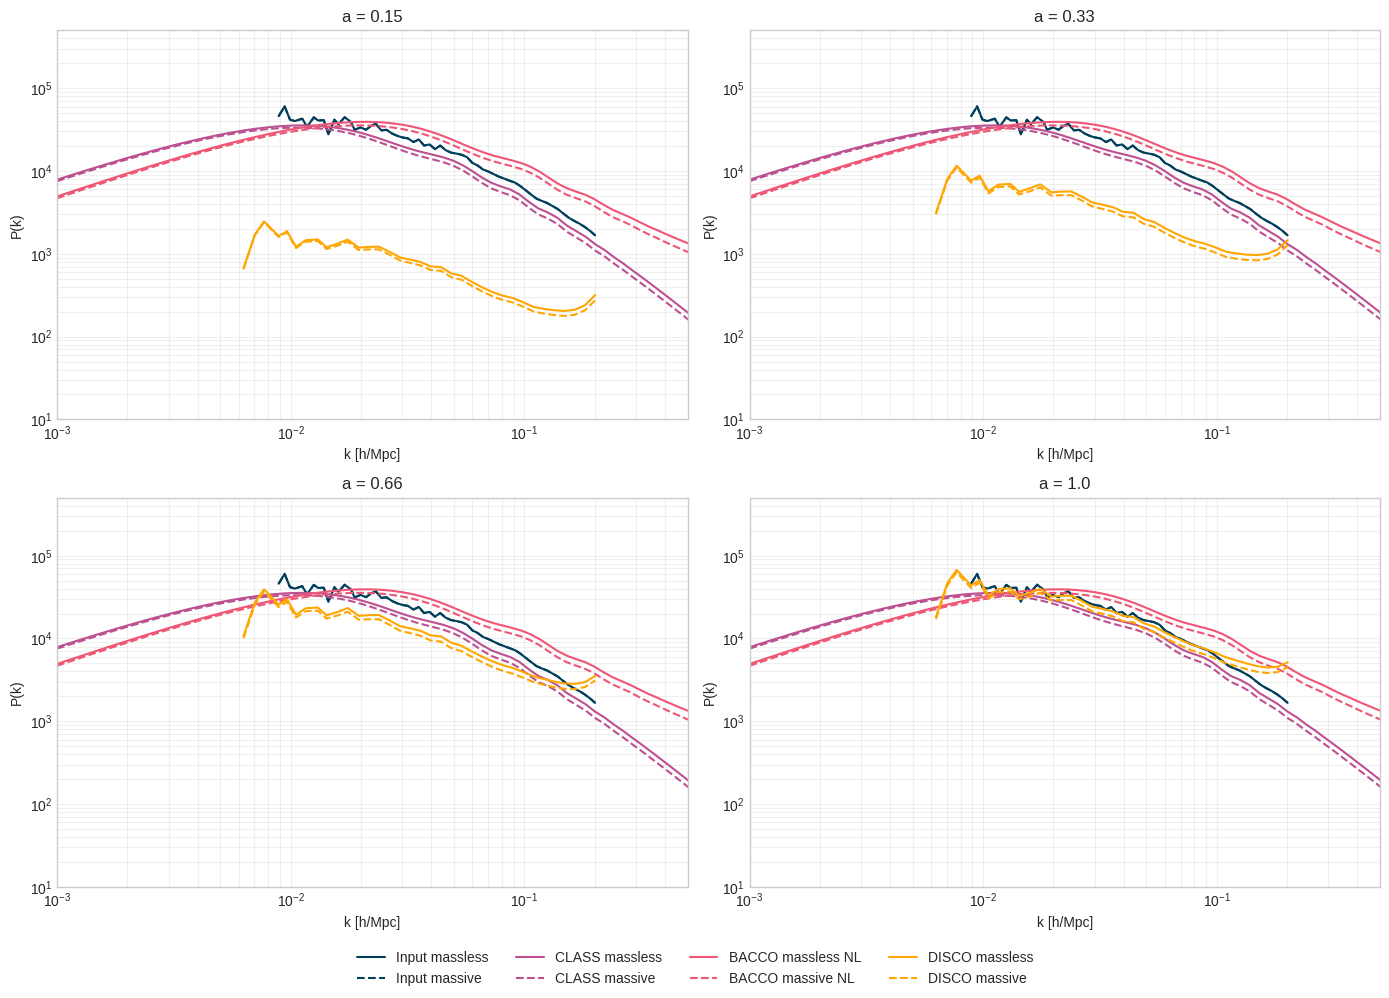

In [32]:
discodj_data = list(np.load("discodj_results.npy", allow_pickle=True))
class_data   = np.load("class_results.npy", allow_pickle=True)
bacco_data_nl   = np.load("bacco_results_nl.npy", allow_pickle=True)

colors = {
    "input": "#003f5c",
    "class": "#bc5090",
    "output": "#ffa600",
    "bacco": "#ef5675"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

bacco_massless = next(d for d in bacco_data_nl if np.isclose(d["mass"], 0.0))
k_bacco_0 = bacco_massless["k"]
pk_bacco_0 = bacco_massless["Pcb"]
bacco_massive =  next(d for d in bacco_data_nl if np.isclose(d["mass"], 0.4))
k_bacco_m = bacco_massive["k"]
pk_bacco_m = bacco_massive["Pcb"]


class_massless = next(d for d in class_data if np.isclose(d["mass"], 0.0))
k_class_0 = class_massless["k"]
pk_class_0 = class_massless["Pcb"]
class_massive =  next(d for d in class_data if np.isclose(d["mass"], 0.4))
k_class_m = class_massive["k"]
pk_class_m = class_massive["Pcb"]



for i, a_end in enumerate(a_targets):

    entries = [d for d in discodj_data if np.isclose(d["a"], a_end)]
    entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
    entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
    k = entry0["k"]
    Pk = entry0["Pcb"]
    Pk_nu = entrym["Pcb"]

    ax = axes[i]
    # -------- INPUT --------
    ax.plot(k_pre, Pk_pre, color=colors["input"], linestyle='-', label="Input massless")
    ax.plot(k_pre_nu, Pk_pre_nu,color=colors["input"], linestyle='--', label="Input massive")

    # -------- CLASS --------
    ax.plot(k_class_0, pk_class_0, color=colors["class"], linestyle='-', label="CLASS massless")
    ax.plot(k_class_m, pk_class_m, color=colors["class"], linestyle='--', label="CLASS massive")
    ax.plot(k_bacco_0, pk_bacco_0, color=colors["bacco"], linestyle='-', label="BACCO massless NL")
    ax.plot(k_bacco_m, pk_bacco_m, color=colors["bacco"], linestyle='--', label="BACCO massive NL")
    # -------- OUTPUT (DISCO) --------
    ax.plot(k, Pk, color=colors["output"], linestyle='-', label="DISCO massless")
    ax.plot(k, Pk_nu, color=colors["output"], linestyle='--', label="DISCO massive")
    ax.set_xlim(1e-3, 0.5)
    ax.set_ylim(10, 5e5)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"a = {a_end}")
    ax.set_xlabel("k [h/Mpc]")
    ax.set_ylabel("P(k)")
    ax.grid(True, which="both", alpha=0.3)

# legend unique
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

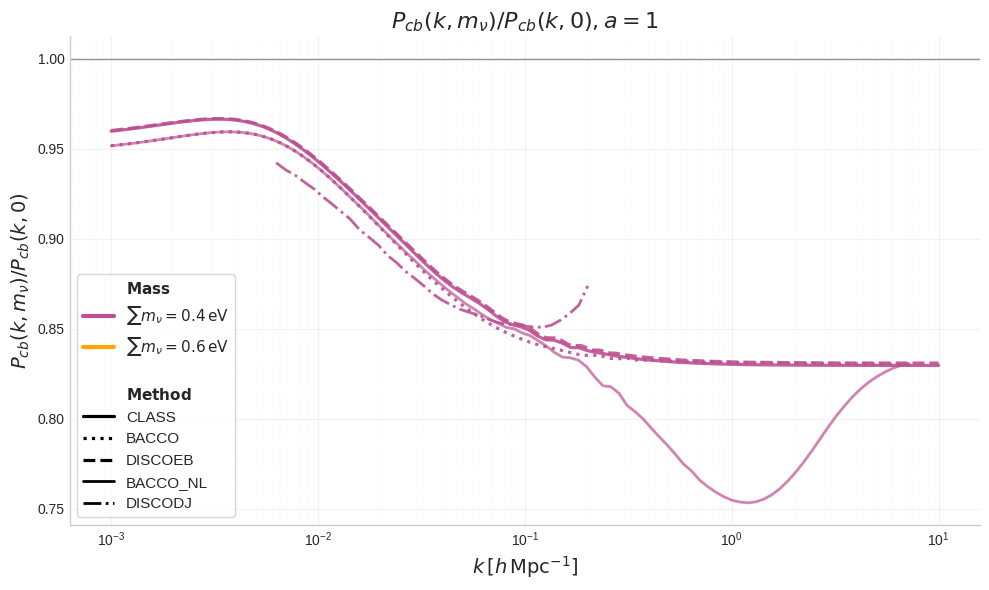

In [33]:
class_data   = np.load("class_results.npy", allow_pickle=True)
bacco_data   = np.load("bacco_results.npy", allow_pickle=True)
bacco_data_nl   = np.load("bacco_results_nl.npy", allow_pickle=True)
discoeb_data = np.load("discoeb_results.npy", allow_pickle=True)
discodj_data = np.load("discodj_results.npy", allow_pickle=True)
discodj_data = [d for d in discodj_data if np.isclose(d["a"], 1)]

all_data = (
    list(class_data)
    + list(bacco_data)
    + list(bacco_data_nl)
    + list(discoeb_data)
    + list(discodj_data)
)

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

# Couleurs = masses
mass_colors = {
    0.0: "#003f5c",
    0.4: "#bc5090",
    0.6: "#ffa600",
}

# Styles = méthodes
method_styles = {
    "CLASS": dict(ls="-",  lw=2.3, alpha=0.9,zorder=2),
    "BACCO": dict(ls=":",  lw=2.3, alpha=0.9,zorder=3),
    "DISCOEB": dict(ls="--", lw=2.3, alpha=0.9,zorder=2),
    "BACCO_NL": dict(ls="-",lw=2.0,alpha=0.7,zorder=3),
    "DISCODJ": dict(ls="-.",lw=2.0,alpha=0.9,zorder=3),
}

reference = {}

for d in all_data:

    mass = d["mass"]

    if not np.isclose(mass, 0.0):
        continue

    method = d["method"]

    if "BACCO_NL" in method:
        key = "BACCO_NL"
    elif "BACCO" in method:
        key = "BACCO"
    elif "CLASS" in method:
        key = "CLASS"
    elif "DISCOEB" in method:
        key = "DISCOEB"
    elif "DISCODJ" in method:
        key = "DISCODJ"

    reference[key] = d["Pcb"]

for d in all_data:

    mass = d["mass"]

    if np.isclose(mass, 0.0):
        continue

    k = d["k"]
    if "BACCO_NL" in d["method"]:
        key = "BACCO_NL"
    elif "BACCO" in d["method"]:
        key = "BACCO"
    elif "CLASS" in d["method"]:
        key = "CLASS"
    elif "DISCOEB" in d["method"]:
        key = "DISCOEB"
    elif "DISCODJ" in d["method"]:
        key = "DISCODJ"

    ratio = d["Pcb"] / reference[key]

    ax.semilogx(
        k,
        ratio,
        color=mass_colors[mass],
        **method_styles[key]
    )

ax.set_xlabel(
    r"$k\,[h\,\mathrm{Mpc}^{-1}]$",
    fontsize=14
)

ax.set_ylabel(
    r"$P_{cb}(k,m_\nu)/P_{cb}(k,0)$",
    fontsize=14
)

ax.axhline(
    1.0,
    color="black",
    lw=1,
    alpha=0.4
)

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

mass_handles = [
    Line2D(
        [0], [0],
        color=mass_colors[m],
        lw=3,
        label=rf"$\sum m_\nu={m}\,\mathrm{{eV}}$"
    )
    for m in [0.4, 0.6]
]

method_handles = [
    Line2D(
        [0], [0],
        color="black",
        ls=method_styles[m]["ls"],
        lw=method_styles[m]["lw"],
        label=m
    )
    for m in method_styles
]

combined_handles = [
    Line2D([], [], color='none', label=r"$\bf{Mass}$"),
    *mass_handles,
    Line2D([], [], color='none', label=""),
    Line2D([], [], color='none', label=r"$\bf{Method}$"),
    *method_handles,
]

ax.legend(
    handles=combined_handles,
    loc="lower left",
    fontsize=11,
    frameon=True,
)

ax.set_title(
    r"$P_{cb}(k,m_\nu)/P_{cb}(k,0), a=1$",
    fontsize=16
)

plt.tight_layout()
plt.show()

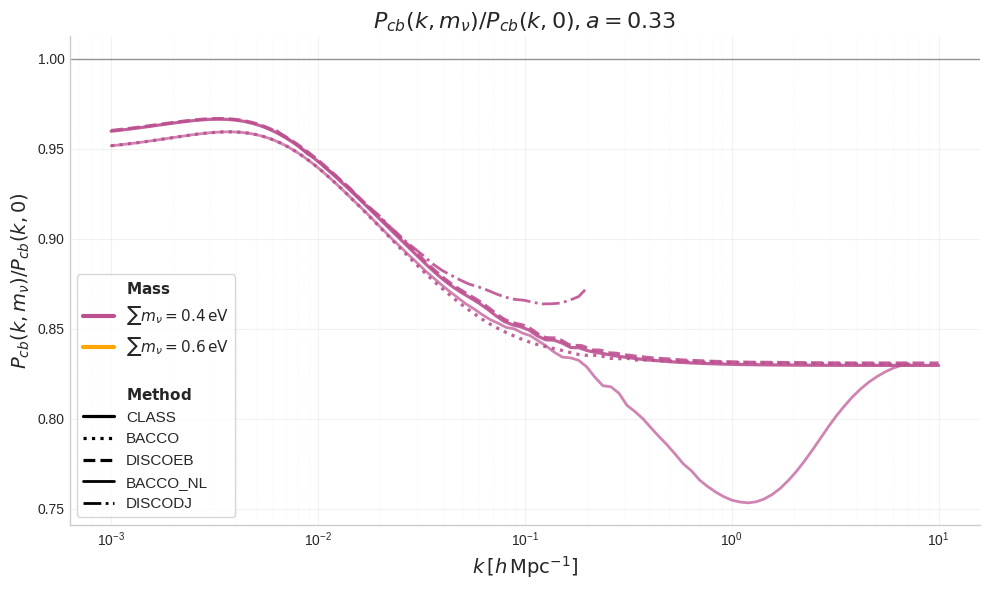

In [34]:
class_data   = np.load("class_results.npy", allow_pickle=True)
bacco_data   = np.load("bacco_results.npy", allow_pickle=True)
bacco_data_nl   = np.load("bacco_results_nl.npy", allow_pickle=True)
discoeb_data = np.load("discoeb_results.npy", allow_pickle=True)
discodj_data = np.load("discodj_results.npy", allow_pickle=True)
discodj_data = [d for d in discodj_data if np.isclose(d["a"], 0.33)]

all_data = (
    list(class_data)
    + list(bacco_data)
    + list(bacco_data_nl)
    + list(discoeb_data)
    + list(discodj_data)
)

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

# Couleurs = masses
mass_colors = {
    0.0: "#003f5c",
    0.4: "#bc5090",
    0.6: "#ffa600",
}

# Styles = méthodes
method_styles = {
    "CLASS": dict(ls="-",  lw=2.3, alpha=0.9,zorder=2),
    "BACCO": dict(ls=":",  lw=2.3, alpha=0.9,zorder=3),
    "DISCOEB": dict(ls="--", lw=2.3, alpha=0.9,zorder=2),
    "BACCO_NL": dict(ls="-",lw=2.0,alpha=0.7,zorder=3),
    "DISCODJ": dict(ls="-.",lw=2.0,alpha=0.9,zorder=3),
}

reference = {}

for d in all_data:

    mass = d["mass"]

    if not np.isclose(mass, 0.0):
        continue

    method = d["method"]

    if "BACCO_NL" in method:
        key = "BACCO_NL"
    elif "BACCO" in method:
        key = "BACCO"
    elif "CLASS" in method:
        key = "CLASS"
    elif "DISCOEB" in method:
        key = "DISCOEB"
    elif "DISCODJ" in method:
        key = "DISCODJ"

    reference[key] = d["Pcb"]

for d in all_data:

    mass = d["mass"]

    if np.isclose(mass, 0.0):
        continue

    k = d["k"]
    if "BACCO_NL" in d["method"]:
        key = "BACCO_NL"
    elif "BACCO" in d["method"]:
        key = "BACCO"
    elif "CLASS" in d["method"]:
        key = "CLASS"
    elif "DISCOEB" in d["method"]:
        key = "DISCOEB"
    elif "DISCODJ" in d["method"]:
        key = "DISCODJ"

    ratio = d["Pcb"] / reference[key]

    ax.semilogx(
        k,
        ratio,
        color=mass_colors[mass],
        **method_styles[key]
    )

ax.set_xlabel(
    r"$k\,[h\,\mathrm{Mpc}^{-1}]$",
    fontsize=14
)

ax.set_ylabel(
    r"$P_{cb}(k,m_\nu)/P_{cb}(k,0)$",
    fontsize=14
)

ax.axhline(
    1.0,
    color="black",
    lw=1,
    alpha=0.4
)

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

mass_handles = [
    Line2D(
        [0], [0],
        color=mass_colors[m],
        lw=3,
        label=rf"$\sum m_\nu={m}\,\mathrm{{eV}}$"
    )
    for m in [0.4, 0.6]
]

method_handles = [
    Line2D(
        [0], [0],
        color="black",
        ls=method_styles[m]["ls"],
        lw=method_styles[m]["lw"],
        label=m
    )
    for m in method_styles
]

combined_handles = [
    Line2D([], [], color='none', label=r"$\bf{Mass}$"),
    *mass_handles,
    Line2D([], [], color='none', label=""),
    Line2D([], [], color='none', label=r"$\bf{Method}$"),
    *method_handles,
]

ax.legend(
    handles=combined_handles,
    loc="lower left",
    fontsize=11,
    frameon=True,
)

ax.set_title(
    r"$P_{cb}(k,m_\nu)/P_{cb}(k,0), a=0.33$",
    fontsize=16
)

plt.tight_layout()
plt.show()